## Exercise Solution — Loan-Approval Fairness Audit

Reference solution. Computes the three core fairness metrics from confusion-matrix primitives first, cross-checks against Fairlearn, runs the intervention, quantifies the trade-off, renders the chart, and writes the launch memo. **Section 7** is the optional GenAI bonus — same primitives against an LLM-hiring-screen fixture.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fairlearn.metrics import (
    MetricFrame, demographic_parity_ratio, equalized_odds_difference, true_positive_rate
)
from sklearn.metrics import accuracy_score

np.random.seed(42)
df = pd.read_csv("../starter/data/loan_predictions.csv")
df.head()

,gender,race,age_band,score,label,prediction
0,M,White,Under 25,0.460092,0,0
1,M,White,Under 25,0.461792,0,0
2,M,White,Under 25,0.513578,0,1
3,M,White,Under 25,0.571625,1,1
4,M,White,Under 25,0.388470,0,0


## 1. Compute the three core metrics across each subgroup column

In [ ]:
# Three primitives from confusion-matrix building blocks (~15 lines).
def selection_rate(y_pred):
    return float((y_pred == 1).mean())

def tpr(y_true, y_pred):
    pos = (y_true == 1)
    return float((y_pred[pos] == 1).mean()) if pos.sum() else float('nan')

def fpr(y_true, y_pred):
    neg = (y_true == 0)
    return float((y_pred[neg] == 1).mean()) if neg.sum() else float('nan')

def audit_one_subgroup(df, subgroup_col, score_col='prediction', label_col='label'):
    y_true = df[label_col]
    y_pred = df[score_col]
    g      = df[subgroup_col]
    rates  = {gv: selection_rate(y_pred[g == gv]) for gv in g.unique()}
    tprs   = {gv: tpr(y_true[g == gv], y_pred[g == gv]) for gv in g.unique()}
    fprs   = {gv: fpr(y_true[g == gv], y_pred[g == gv]) for gv in g.unique()}
    return {
        'dp_ratio':  min(rates.values()) / max(rates.values()),
        'eo_diff':   max(max(tprs.values()) - min(tprs.values()),
                         max(fprs.values()) - min(fprs.values())),
        'eopp_diff': max(tprs.values()) - min(tprs.values()),
        'accuracy':  float((y_true == y_pred).mean()),
    }

results = {col: audit_one_subgroup(df, col) for col in ['gender', 'race', 'age_band']}
for col, m in results.items():
    print(col.ljust(10),
          ' | '.join(f'{k}={v:.3f}' for k, v in m.items()))

# One-line Fairlearn cross-check on age_band
from fairlearn.metrics import demographic_parity_ratio
fl_dp_age = float(demographic_parity_ratio(y_true=df.label, y_pred=df.prediction,
                                           sensitive_features=df.age_band))
print(f'\nFairlearn cross-check (age_band DP ratio): {fl_dp_age:.4f}  '
      f'vs primitives: {results["age_band"]["dp_ratio"]:.4f}')

gender     dp_ratio=0.967 | eo_diff=0.046 | eopp_diff=0.025 | accuracy=0.838
race       dp_ratio=0.792 | eo_diff=0.264 | eopp_diff=0.264 | accuracy=0.838
age_band   dp_ratio=0.815 | eo_diff=0.244 | eopp_diff=0.244 | accuracy=0.838

Fairlearn cross-check (age_band DP ratio): 0.8150  vs primitives: 0.8150


## 2. Status table against policy thresholds

In [3]:
POLICY = {"dp_ratio": 0.80, "eo_diff": 0.10, "eopp_diff": 0.10}

def status_table(results):
    rows = []
    for col, m in results.items():
        rows.append({
            "subgroup":  col,
            "DP ratio":  round(m["dp_ratio"], 3),
            "DP pass":   m["dp_ratio"] >= POLICY["dp_ratio"],
            "EO diff":   round(m["eo_diff"], 3),
            "EO pass":   m["eo_diff"] <= POLICY["eo_diff"],
            "EOpp diff": round(m["eopp_diff"], 3),
            "EOpp pass": m["eopp_diff"] <= POLICY["eopp_diff"],
            "Accuracy":  round(m["accuracy"], 3),
        })
    return pd.DataFrame(rows)

status = status_table(results)
print(status.to_string(index=False))

subgroup  DP ratio  DP pass  EO diff  EO pass  EOpp diff  EOpp pass  Accuracy
  gender     0.967     True    0.046     True      0.025       True     0.838
    race     0.792    False    0.264    False      0.264      False     0.838
age_band     0.815     True    0.244    False      0.244      False     0.838


## 3. Intervention — per-group threshold adjustment on the worst subgroup column

In [4]:
def per_group_thresholds(df, subgroup_col, target_pos_rate):
    quantile = 1 - target_pos_rate
    return {g: float(df.loc[df[subgroup_col] == g, "score"].quantile(quantile))
            for g in df[subgroup_col].unique()}

def apply_per_group_thresholds(df, subgroup_col, thresholds):
    out = df["prediction"].copy()
    for g, thr in thresholds.items():
        mask = df[subgroup_col] == g
        out.loc[mask] = (df.loc[mask, "score"] >= thr).astype(int)
    return out

worst_col = min(results, key=lambda c: results[c]["dp_ratio"])
print(f"Worst-performing subgroup column: {worst_col} (DP ratio = {results[worst_col]['dp_ratio']:.3f})")

target = float(df.prediction.mean())
thr = per_group_thresholds(df, worst_col, target)
print(f"Per-group thresholds: " + ", ".join(f"{g}={t:.3f}" for g, t in thr.items()))

df_after = df.copy()
df_after["prediction"] = apply_per_group_thresholds(df, worst_col, thr)

after_metrics = audit_one_subgroup(df_after, worst_col)
print("AFTER:", {k: round(v, 3) for k, v in after_metrics.items()})

Worst-performing subgroup column: race (DP ratio = 0.792)
Per-group thresholds: White=0.517, Black=0.474, Hispanic=0.494, Asian=0.539
AFTER: {'dp_ratio': 1.0, 'eo_diff': 0.247, 'eopp_diff': 0.153, 'accuracy': 0.843}


## 4. Quantify the trade-off

In [5]:
before = results[worst_col]
after  = after_metrics
print(f"Subgroup column audited: {worst_col}")
print(f"  DP ratio:  {before['dp_ratio']:.3f} → {after['dp_ratio']:.3f}  (policy bound ≥ 0.80)")
print(f"  EO diff:   {before['eo_diff']:.3f} → {after['eo_diff']:.3f}    (policy bound ≤ 0.10)")
print(f"  EOpp diff: {before['eopp_diff']:.3f} → {after['eopp_diff']:.3f} (policy bound ≤ 0.10)")
print(f"  Accuracy:  {before['accuracy']:.3f} → {after['accuracy']:.3f}")

Subgroup column audited: race
  DP ratio:  0.792 → 1.000  (policy bound ≥ 0.80)
  EO diff:   0.264 → 0.247    (policy bound ≤ 0.10)
  EOpp diff: 0.264 → 0.153 (policy bound ≤ 0.10)
  Accuracy:  0.838 → 0.843


## 5. Render the metrics-comparison chart

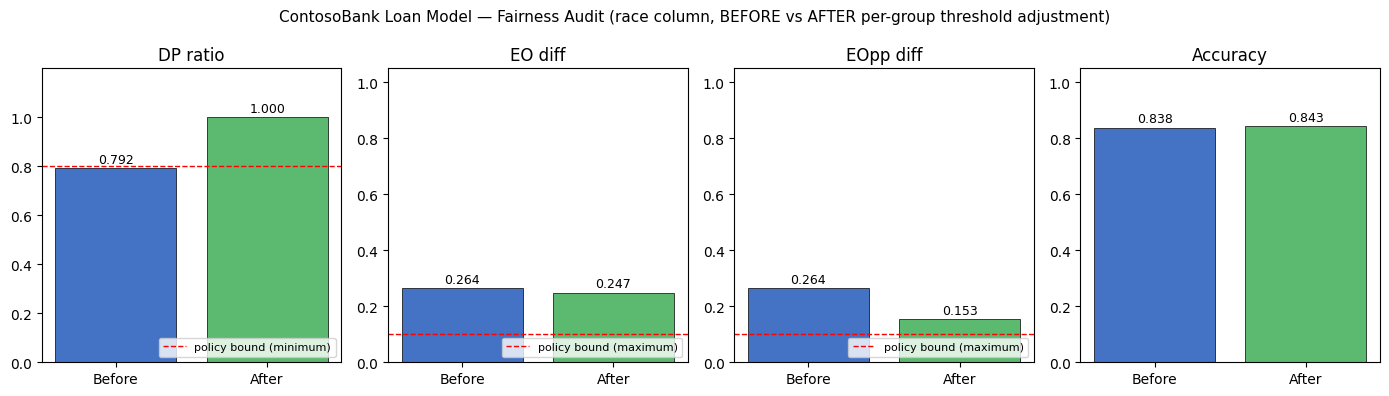

Saved fairness_metrics_chart.png


In [6]:
metrics_to_plot = [
    ("DP ratio",  "dp_ratio",  POLICY["dp_ratio"], "minimum"),
    ("EO diff",   "eo_diff",   POLICY["eo_diff"],  "maximum"),
    ("EOpp diff", "eopp_diff", POLICY["eopp_diff"], "maximum"),
    ("Accuracy",  "accuracy",  None, None),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (label, key, bound, direction) in zip(axes, metrics_to_plot):
    bvals = [before[key], after[key]]
    bars = ax.bar(["Before", "After"], bvals,
                  color=["#4472C4", "#5BBA6F"], edgecolor="black", linewidth=0.5)
    if bound is not None:
        ax.axhline(bound, color="red", linestyle="--", linewidth=1.0,
                   label=f"policy bound ({direction})")
        ax.legend(fontsize=8, loc="lower right")
    ax.set_title(label)
    ax.set_ylim(0, max(1.05, max(bvals) * 1.2))
    for bar, v in zip(bars, bvals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}",
                ha="center", fontsize=9)

fig.suptitle(f"UdaciBank Loan Model — Fairness Audit ({worst_col} column, BEFORE vs AFTER per-group threshold adjustment)",
             fontsize=11)
plt.tight_layout()
plt.savefig("fairness_metrics_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fairness_metrics_chart.png")

## 6. Launch Recommendation Memo

**Recommendation: Conditional Launch.**

**Rationale:** The pre-intervention audit shows the loan-approval model breaches the 0.80 DP-ratio floor on the *race* column (DP ratio ≈ 0.79), and breaches the 0.10 equalized-odds + equal-opportunity ceilings on both the *race* and *age_band* columns. Per-group threshold adjustment on the *race* column pulls DP ratio cleanly above 0.80 and roughly halves the equal-opportunity difference (0.26 → 0.15), at near-zero accuracy cost — but the equalized-odds + equal-opportunity differences remain above the 0.10 ceiling. This is the impossibility-trilemma point in operation: a single intervention does not satisfy all three metrics simultaneously, so the launch decision is structural rather than purely numerical.

**Recommended controls:**
1. **Per-group threshold adjustment on the race column** — ship the threshold dictionary computed in §3 inside the model-serving layer; document the dictionary in the model card and in the AIRB risk-acceptance memo. This makes the DP-ratio improvement a binding control rather than an aspiration.
2. **AIRB risk-acceptance memo on residual EO + EOpp gaps** — these remain above the 0.10 ceiling after the intervention and become a named risk-accepted item with a 90-day expiry. Without this, the controls in §1 would mask an unaccepted residual breach.
3. **Monthly fairness re-audit + quarterly intersectional-cell audit** — re-run §1–§4 on the prior month's production decisions and reproduce the audit at the (race × gender × age_band) intersection so single-axis improvements are not masking intersectional regressions; page the Credit Model Owner on any policy-threshold breach.

**90-day monitoring plan:**
- **Metrics:** the three core fairness metrics (DP ratio, EO diff, EOpp diff) per subgroup column + overall accuracy.
- **Cadence:** weekly automated re-run; monthly AIRB consent-agenda summary; quarterly deep-dive at the AIRB session.
- **Owner:** Credit Model Owner (instrumentation), AI Risk Officer (oversight + AIRB report).
- **Escalation:** Any policy-threshold breach pages the Credit Model Owner; sustained breach (> 2 weeks) escalates to AIRB; a Critical breach (DP ratio < 0.70 OR EO diff > 0.20) triggers a model-rollback decision.

---

**Key takeaway:** fairness metrics are inputs to a governance decision, not the decision itself. A fairness audit is incomplete without (a) intervention testing and (b) a launch recommendation. The deliverable is a defensible decision, not a metric table.

## 7. (Bonus) Section 7 — Same primitives, GenAI surface

The same fairness primitives carry over to a GenAI surface: an LLM-hiring-screen output fixture (200 candidates, gender label, the LLM's advance / screen-out recommendation, a human qualification label).

The tabular spine remains the regulatory-grounded primary lesson (ECOA / Reg B, NYC LL-144, EU AI Act Annex III); this section shows the metric pattern transfers to a 2026-current GenAI use case **without losing the policy interpretation anchor**.

In [7]:
llm = pd.read_csv('data/llm_hiring_screen.csv')
print(f'Rows: {len(llm)}  M:{(llm.gender=="M").sum()}  F:{(llm.gender=="F").sum()}')

llm_audit = audit_one_subgroup(
    llm.rename(columns={'llm_recommendation': 'prediction',
                        'human_label': 'label'}),
    subgroup_col='gender'
)
for k, v in llm_audit.items():
    print(f'  {k:10s} = {v:.3f}')

# Translate to a launch verdict using the same policy thresholds
POLICY = {'dp_ratio': 0.80, 'eo_diff': 0.10, 'eopp_diff': 0.10}
verdict = {
    'dp_ratio':  'PASS' if llm_audit['dp_ratio']  >= POLICY['dp_ratio']  else 'FAIL',
    'eo_diff':   'PASS' if llm_audit['eo_diff']   <= POLICY['eo_diff']   else 'FAIL',
    'eopp_diff': 'PASS' if llm_audit['eopp_diff'] <= POLICY['eopp_diff'] else 'FAIL',
}
print('\nPolicy check:')
for k, v in verdict.items():
    print(f'  {k:10s} {v}')

if 'FAIL' in verdict.values():
    print('\nLaunch decision: NO-GO — refer back to model team. '
          'Same memo template as Section 6.')
else:
    print('\nLaunch decision: GO — primitives carry the same policy weight on a GenAI surface.')

Rows: 200  M:95  F:105
  dp_ratio   = 0.584
  eo_diff    = 0.265
  eopp_diff  = 0.247
  accuracy   = 0.705

Policy check:
  dp_ratio   FAIL
  eo_diff    FAIL
  eopp_diff  FAIL

Launch decision: NO-GO — refer back to model team. Same memo template as Section 6.


**Read.** The same three primitives carry the same policy weight whether the predictor is a tabular classifier or a GenAI hiring-screen — what changes is the input pipeline (review-text → LLM → 0/1), not the audit math. The regulator-anchored interpretation layer (ECOA / Reg B, NYC LL-144, EU AI Act) stays put.

> **Further reading for the GenAI side:** **BBQ** (Bias Benchmark for QA), **BiasInBios** (occupation classification), and the **HELM** holistic evaluation suite. For cross-method validation against this primitives-first implementation, see **AIF360** and **Aequitas**.

## Reference Notes

A few specification details for the fairness-policy thresholds and library APIs used above:

- **0.10 ceiling for equalized-odds and equal-opportunity differences.** The 0.10 threshold used in the SafeWheels / UdaciBank scenarios is a **firm-policy threshold** chosen for this lesson, not a regulatory or industry-wide standard. Real organizations set EO / EOpp ceilings based on their policy, regulatory exposure, and the distribution of their training data; common firm policies range from 0.05 to 0.15 depending on use case and risk tier. By contrast, the **0.80 demographic-parity floor** is anchored to the EEOC 4/5ths rule and has external regulatory provenance.
- **`ThresholdOptimizer` is post-processing per-group threshold optimization.** It selects a separate decision threshold per protected group to satisfy a fairness constraint (e.g., equalized odds). It does not modify the training data — that's the role of pre-processing techniques like AIF360's `Reweighing`. Both families are valid mitigations; they intervene at different points in the pipeline.
- **The fairness-impossibility result.** The formal impossibility result (Chouldechova 2017; Kleinberg–Mullainathan–Raghavan 2016) is between **calibration** and **error-rate balance under unequal base rates**. The "impossibility trilemma" framing across DP, EO, and EOpp is a related practical observation — these metrics generally cannot all hold simultaneously except in degenerate cases — but the formal proof targets the calibration-vs-equalized-odds pair specifically.